In [1]:
# Imports & helper settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss


sns.set_style(style="whitegrid")

In [2]:
# Load the Air Passengers dataset
air = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",
    parse_dates=["Month"],
)

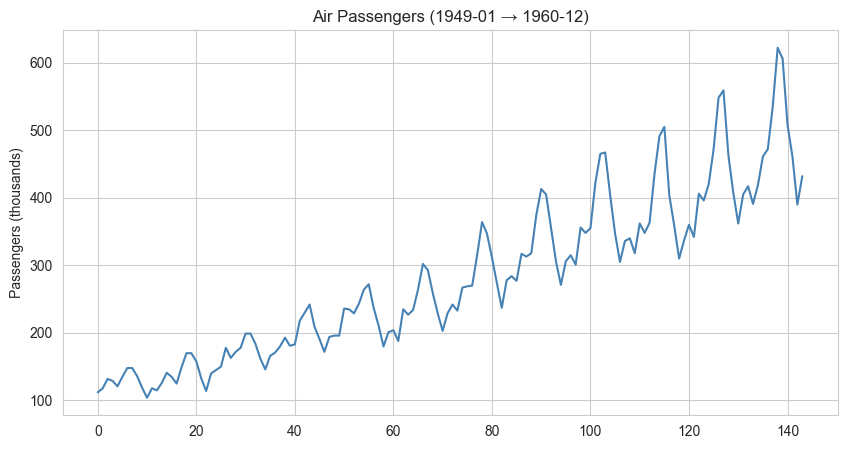

In [3]:
# Basic time‑series plot
fig, ax = plt.subplots(figsize=(10, 5))
air.plot(y="Passengers", ax=ax, color="steelblue", legend=False)
ax.set_title("Air Passengers (1949-01 → 1960-12)")
ax.set_ylabel("Passengers (thousands)")
plt.show()

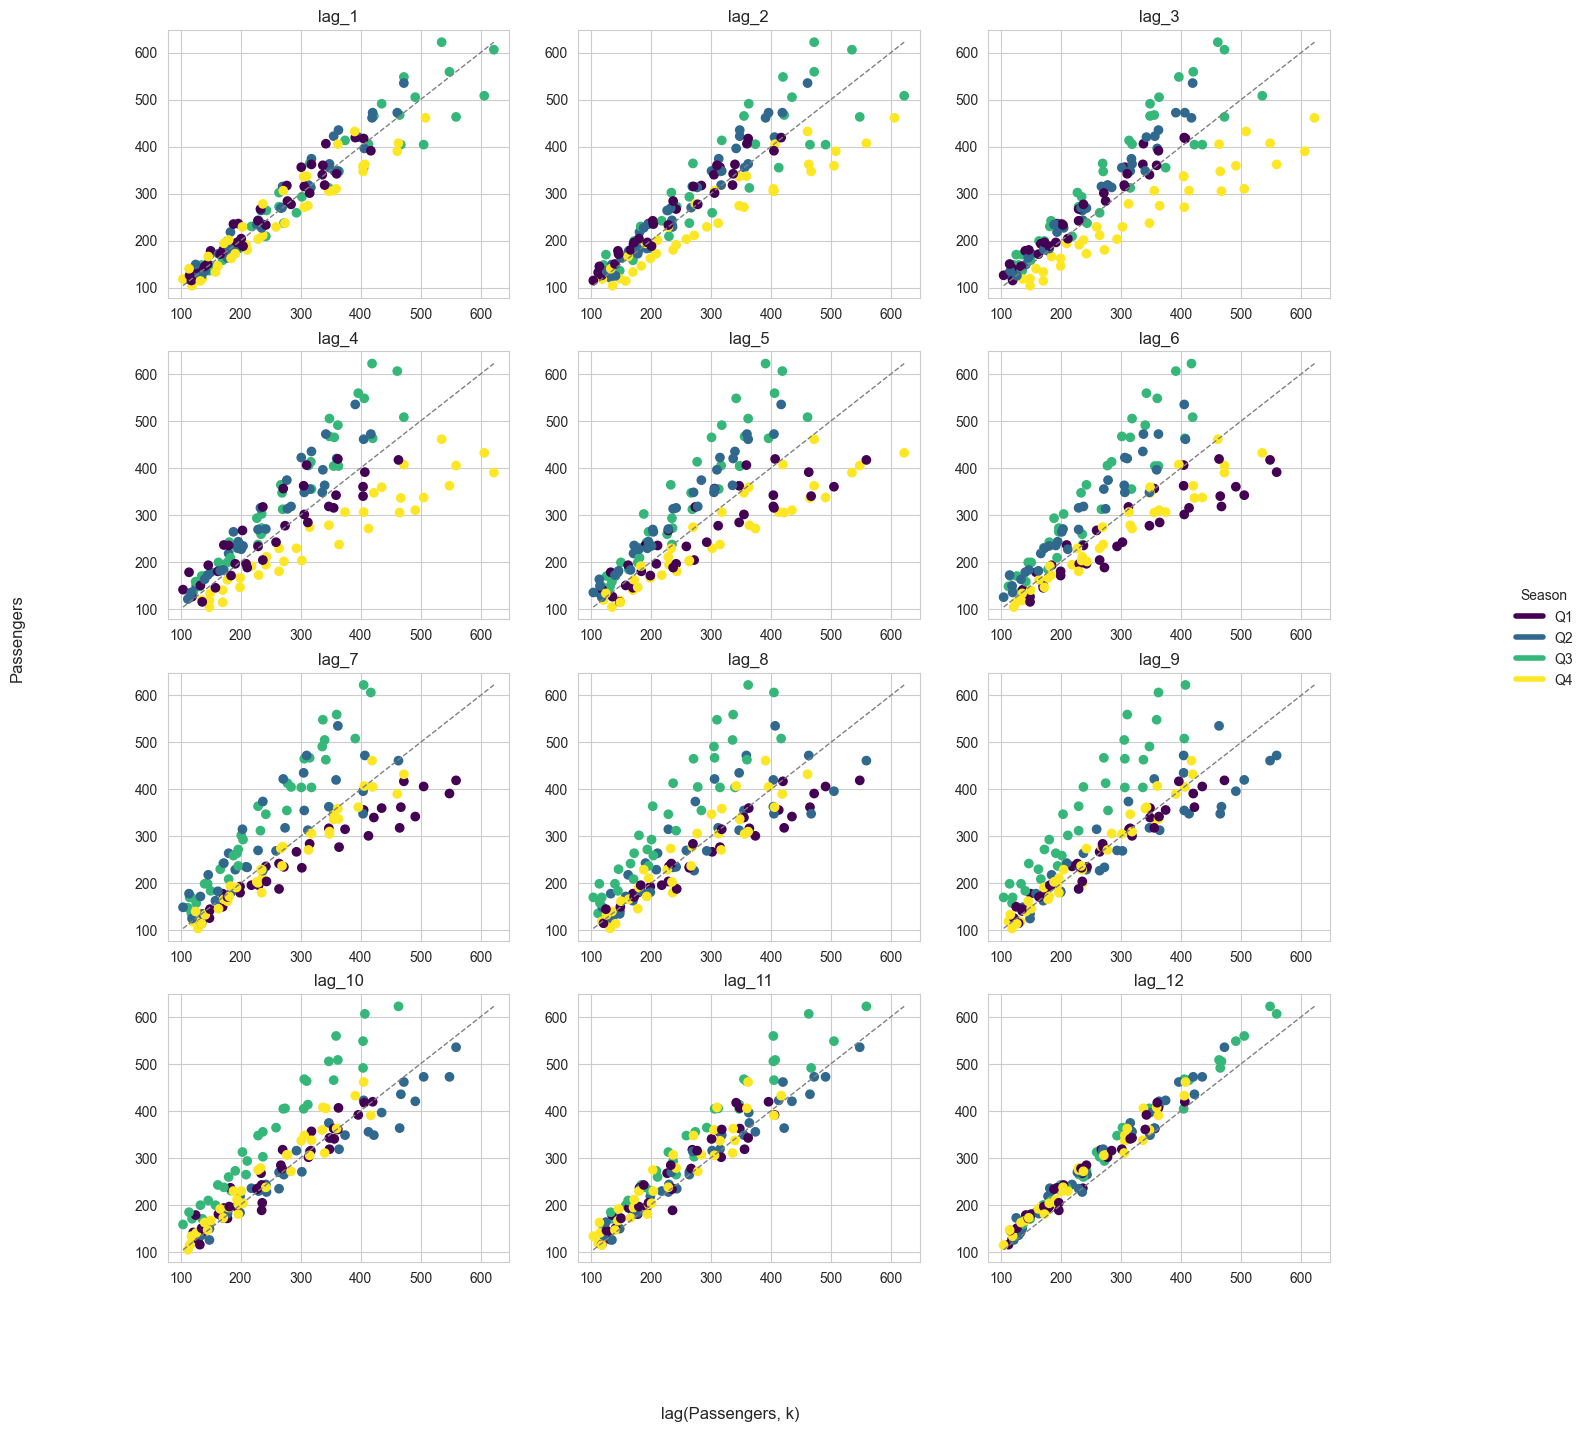

In [4]:
max_lag = 12
for lag in range(1, max_lag + 1):
    air[f"lag_{lag}"] = air["Passengers"].shift(lag)

air["Quarter"] = air["Month"].dt.quarter
lags = [f"lag_{i}" for i in range(1, max_lag + 1)]
lims = [
    np.min([air[lag].min() for lag in lags] + [air["Passengers"].min()]),
    np.max([air[lag].max() for lag in lags] + [air["Passengers"].max()]),
]
fig, axes = plt.subplots(max_lag // 3, 3, figsize=(15, max_lag // 3 * (3 + 1)))
for ax, lag in zip(axes.flatten(), lags):
    ax.scatter(
        air[lag],
        air["Passengers"],
        c=air["Quarter"],
        cmap="viridis",
    )
    ax.plot(lims, lims, "grey", linestyle="--", linewidth=1)
    ax.set_title(lag)

unique_quarters = sorted(air["Quarter"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_quarters)))
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in colors]
labels = [f"Q{q}" for q in unique_quarters]
fig.legend(
    handles,
    labels,
    title="Season",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0,
)

fig.supxlabel("lag(Passengers, k)")
fig.supylabel("Passengers")
plt.show()

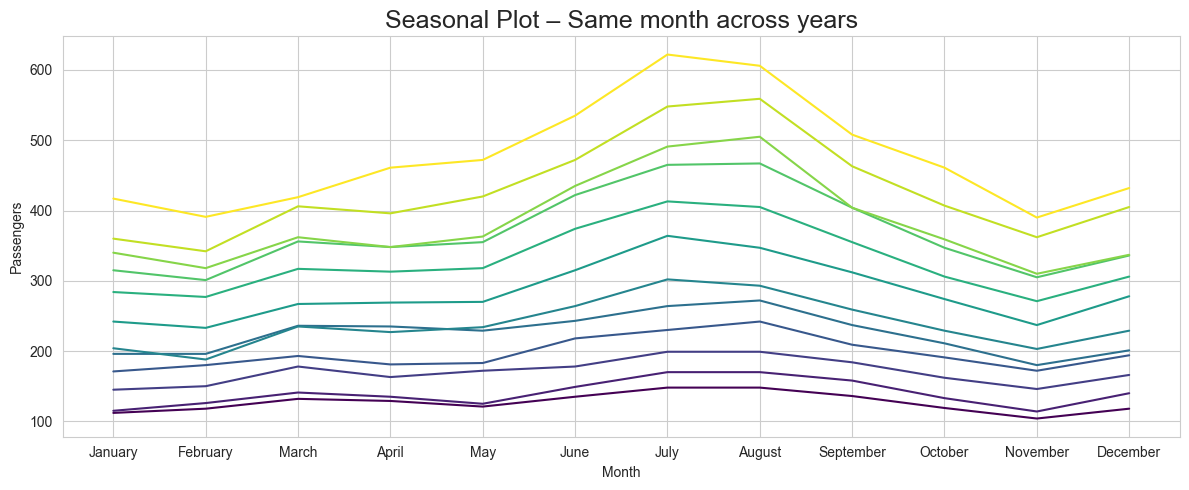

In [5]:
# Seasonal (month‑wise) plot
# Create a column for month name & year for grouping
df = air.copy()
df["MonthName"] = df["Month"].dt.month_name()
df["Year"] = df["Month"].dt.year

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x="MonthName",
    y="Passengers",
    hue="Year",
    palette="viridis",
    legend=False,
)
plt.title("Seasonal Plot – Same month across years", size=18)
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

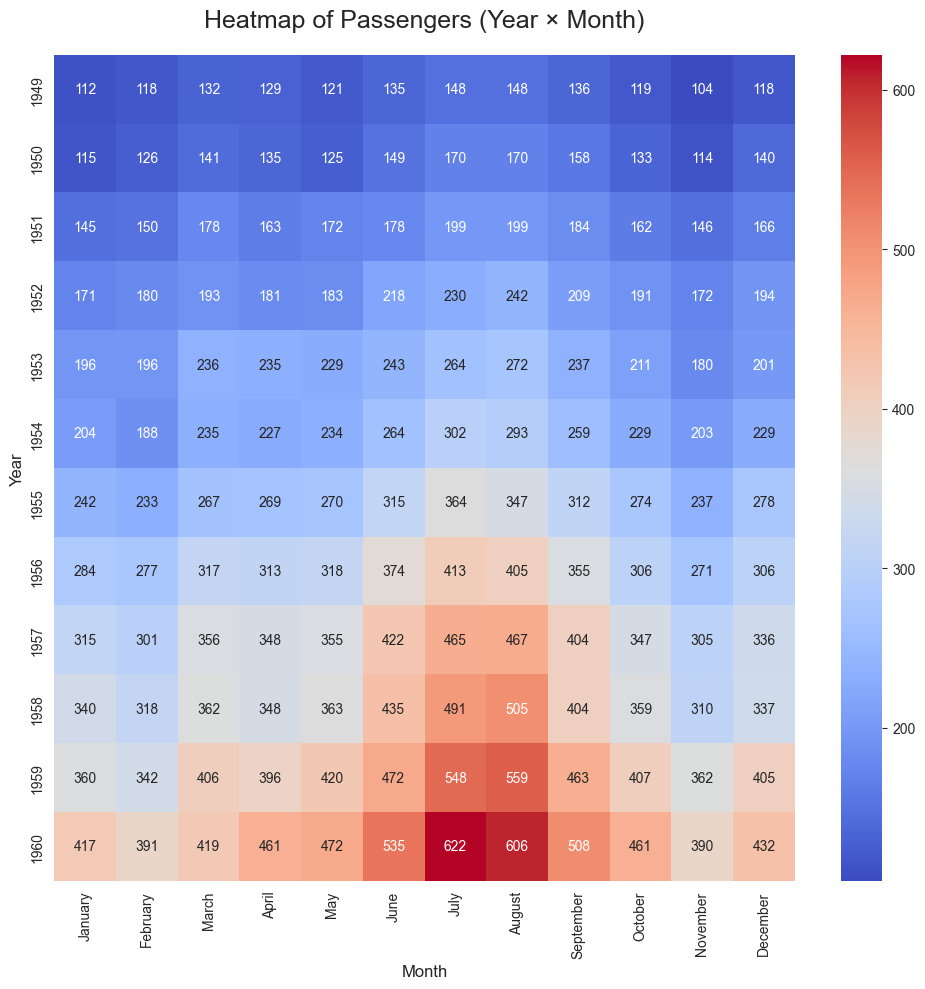

In [6]:
# Seasonal heat‑map (month vs. year)
pivot = df.pivot_table(
    values="Passengers",
    index="Year",
    columns="MonthName",
    aggfunc="mean",
)
# Ensure months are ordered Jan→Dec
pivot = pivot[
    [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]
]

_, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot, cmap="coolwarm", annot=True, fmt=".0f", ax=ax)
plt.title("Heatmap of Passengers (Year × Month)", size=18, pad=20)
plt.xlabel("Month", size=12)
plt.ylabel("Year", size=12)
plt.tight_layout()
plt.show()

In [7]:
# Stationarity tests – ADF & KPSS


def adf_report(series):
    result = adfuller(series, autolag="AIC")
    print("\n=== Augmented Dickey‑Fuller Test ===")
    print(f"ADF Statistic   : {result[0]:.4f}")
    print(f"P‑value         : {result[1]:.4f}")
    print("Critical values :")
    for key, val in result[4].items():
        print(f"   {key} : {val:.4f}")
    if result[1] < 0.05:
        print("=> Reject H0 – the series is stationary.")
    else:
        print("=> Fail to reject H0 – the series is non‑stationary.")


def kpss_report(series, regression="c"):
    result = kpss(series, regression=regression, nlags="auto")
    print("\n=== KPSS Test ===")
    print(f"KPSS Statistic  : {result[0]:.4f}")
    print(f"P‑value         : {result[1]:.4f}")
    print("Critical values :")
    for key, val in result[3].items():
        print(f"   {key} : {val:.4f}")
    if result[1] < 0.05:
        print("=> Reject H0 – the series is NOT stationary (has a unit root).")
    else:
        print("=> Fail to reject H0 – the series is stationary.")


# Run tests on the raw series
adf_report(air["Passengers"])
kpss_report(air["Passengers"], regression="c")  # constant only (no trend)


=== Augmented Dickey‑Fuller Test ===
ADF Statistic   : 0.8154
P‑value         : 0.9919
Critical values :
   1% : -3.4817
   5% : -2.8840
   10% : -2.5788
=> Fail to reject H0 – the series is non‑stationary.

=== KPSS Test ===
KPSS Statistic  : 1.6513
P‑value         : 0.0100
Critical values :
   10% : 0.3470
   5% : 0.4630
   2.5% : 0.5740
   1% : 0.7390
=> Reject H0 – the series is NOT stationary (has a unit root).


/var/folders/5_/7z8lzq913cl3q8m0z5pnmpjr0000gn/T/ipykernel_1150/1608899063.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression=regression, nlags="auto")


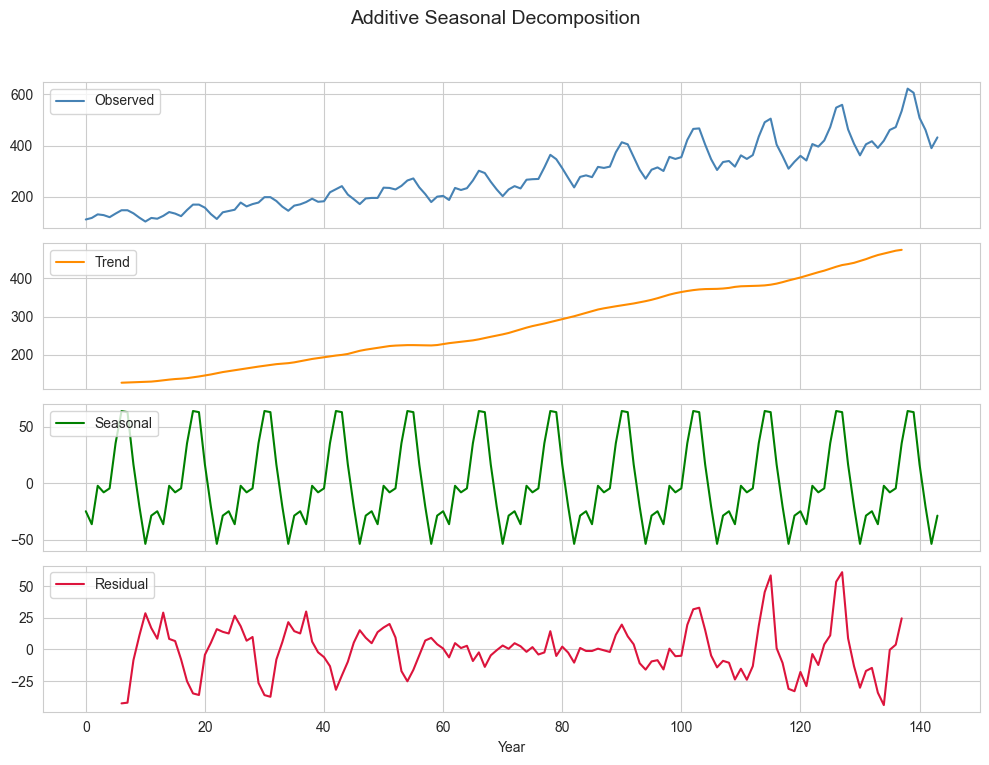

In [8]:
# Seasonal decomposition (additive) – main analysis
decomp = seasonal_decompose(air["Passengers"], model="additive", period=12)

# Plot the four components
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
axes[0].plot(air["Passengers"], label="Observed", color="steelblue")
axes[0].legend(loc="upper left")

axes[1].plot(decomp.trend, label="Trend", color="darkorange")
axes[1].legend(loc="upper left")

axes[2].plot(decomp.seasonal, label="Seasonal", color="green")
axes[2].legend(loc="upper left")

axes[3].plot(decomp.resid, label="Residual", color="crimson")
axes[3].legend(loc="upper left")
axes[3].set_xlabel("Year")

fig.suptitle("Additive Seasonal Decomposition", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [21]:
# Component‑strength metrics (trend & seasonality)
# Drop NaNs that appear at the edges of trend/residual series
trend = decomp.trend.dropna()
seasonal = decomp.seasonal.dropna()
resid = decomp.resid.dropna()

trend_strength = 1 - np.var(resid) / np.var(trend + resid)
season_strength = 1 - np.var(resid) / np.var(seasonal + resid)

print(f"Trend strength      : {trend_strength:.3f}")
print(f"Seasonality strength: {season_strength:.3f}")

Trend strength      : 0.966
Seasonality strength: 0.779


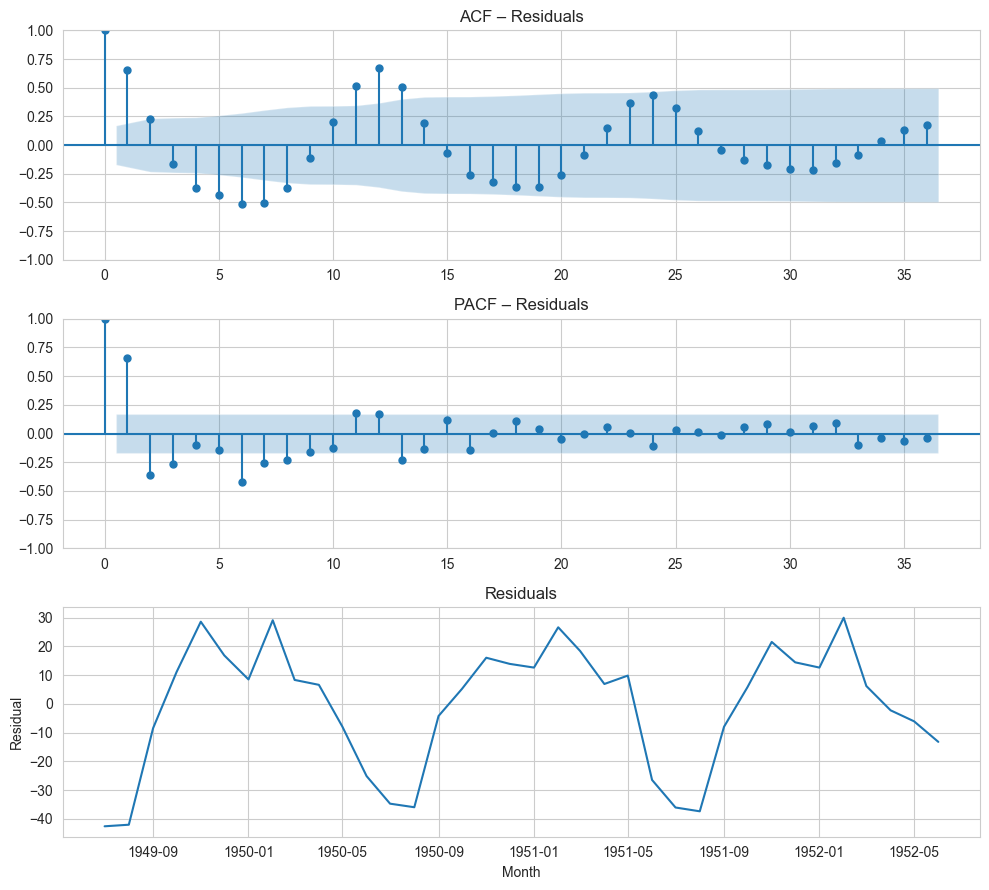

In [22]:
# ACF & PACF of the residuals (post‑decomposition check)
fig, ax = plt.subplots(3, 1, figsize=(10, 9))
n_lags = 36
plot_acf(resid, lags=n_lags, ax=ax[0], title="ACF – Residuals")
plot_pacf(resid, lags=n_lags, ax=ax[1], title="PACF – Residuals")

# Quick visual: residuals should look like white noise
sns.lineplot(x=air.iloc[resid.index[:n_lags]]["Month"], y=resid[:n_lags], ax=ax[2])
ax[2].set_title("Residuals")
ax[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

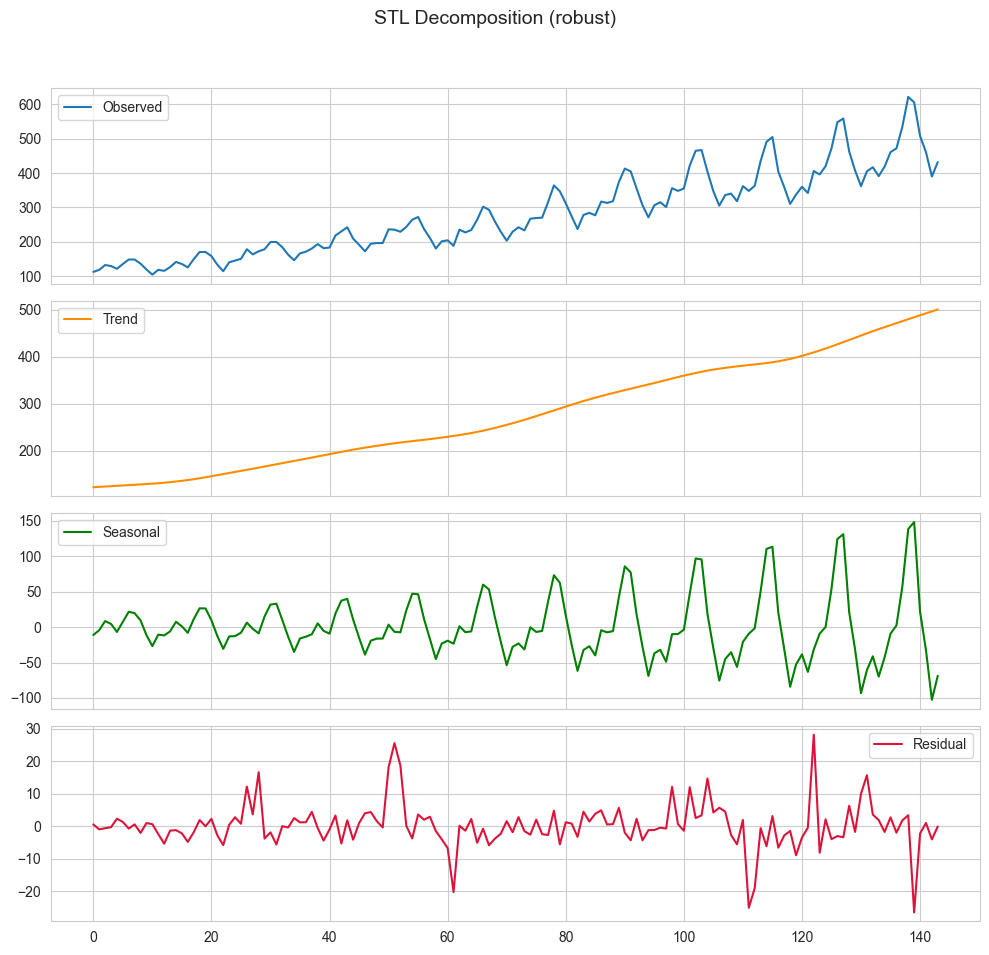

In [ ]:
# STL (Seasonal Trend Decomposition using LOESS) decomposition - robust to outliers
# LOESS (https://en.wikipedia.org/wiki/Local_regression)

stl = STL(air["Passengers"], period=12, robust=True)
stl_res = stl.fit()

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
axes[0].plot(stl_res.observed, label="Observed")
axes[0].legend()

axes[1].plot(stl_res.trend, label="Trend", color="darkorange")
axes[1].legend()

axes[2].plot(stl_res.seasonal, label="Seasonal", color="green")
axes[2].legend()

axes[3].plot(stl_res.resid, label="Residual", color="crimson")
axes[3].legend()

plt.suptitle("STL Decomposition (robust)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [24]:
print(
    "\n=== Summary of Findings ===\n"
    "• The raw series exhibits strong upward trend & clear yearly seasonality.\n"
    "• Lag plot and ACF/PACF of the raw series show significant autocorrelation.\n"
    "• ADF fails to reject the unit‑root null (p > 0.05) → non‑stationary.\n"
    "• KPSS rejects stationarity (p < 0.05) → confirms a unit‑root.\n"
    "• Trend strength = {trend_strength:.2f} (close to 1 → trend dominates)\n"
    "• Seasonal strength = {season_strength:.2f} (also high).\n"
    "• Residual ACF/PACF are within 95 % confidence bands → residuals ≈ white noise.\n"
    "• Decomposition therefore captures the systematic components well.\n"
    "Next steps:\n"
    " 1. Difference the series (or take log‑diff) and re‑run ADF/KPSS.\n"
    " 2. Fit a simple ARIMA or SARIMA model on the differenced series.\n"
    " 3. Compare forecasts from the decomposition‑based naïve method vs. ARIMA"
)


=== Summary of Findings ===
• The raw series exhibits strong upward trend & clear yearly seasonality.
• Lag plot and ACF/PACF of the raw series show significant autocorrelation.
• ADF fails to reject the unit‑root null (p > 0.05) → non‑stationary.
• KPSS rejects stationarity (p < 0.05) → confirms a unit‑root.
• Trend strength = {trend_strength:.2f} (close to 1 → trend dominates)
• Seasonal strength = {season_strength:.2f} (also high).
• Residual ACF/PACF are within 95 % confidence bands → residuals ≈ white noise.
• Decomposition therefore captures the systematic components well.
Next steps:
 1. Difference the series (or take log‑diff) and re‑run ADF/KPSS.
 2. Fit a simple ARIMA or SARIMA model on the differenced series.
 3. Compare forecasts from the decomposition‑based naïve method vs. ARIMA
